In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sedpy.observate import getSED, load_filters
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from scipy.special import logsumexp
import time
from scipy.special import ndtri as norm_ppf
from scipy.stats import norm as _norm
from glob import glob
from sklearn.decomposition import NMF

# Template functions

In [2]:
def templates(wave,flux, normal='L1'):
    # Assume input is f_lambda
    wave_grid = np.linspace(800, 50000, 20000)
    dx = np.abs(np.gradient(wave_grid))
    flux_interp = {}
    c_angstrom = 2.99792458e18

    for i,f in enumerate(flux):   
        flux_lam_interp = np.interp(wave_grid, wave, f)
        

        if normal == 'L1':
            norm = np.sum(np.abs(flux_lam_interp) * dx)
            flux_norm = flux_lam_interp / norm

        elif normal == 'L2':
            norm = np.sqrt(np.sum((flux_lam_interp**2) * dx))
            flux_norm = flux_lam_interp / norm

        else:
            raise ValueError("normal must be 'L1' or 'L2'")

        flux_interp[i] = flux_norm

    flux_list = []
    for name in flux_interp.keys():
        flux_list.append(flux_interp[name])

    return flux_list

In [19]:
def run_nmf(X,n):
    model = NMF(n_components=n, tol=1e-3, max_iter=500)
    W = model.fit_transform(X)
    H = model.components_
    return W,H

# Redshifting PCA

In [4]:
fil=['cfht_u','sc_IB427','sc_IB464','hsc_g','subaru_suprimecam_ia484','sc_IB505','subaru_suprimecam_ia527','sc_IB574','subaru_suprimecam_ia624','hsc_r','subaru_suprimecam_ia679','sc_IB709','sc_NB711','subaru_suprimecam_ia738',
    'subaru_suprimecam_ia767','hsc_i','sc_NB816','sc_IB827','hsc_z','hsc_y','vista_vircam_H','vista_vircam_Ks','vista_vircam_J','vista_vircam_Y','irac_ch1','irac_ch2']

filters = load_filters(fil)

In [5]:
def redshiftpca(filters,wave_grid,H):
    # assume H in cgs
    z_grid=np.linspace(0,8,501)
    z_grid=z_grid[1:]
    
    f_z = {}
    wave_z = {}
    H = np.asarray(H)
    wave_grid = np.asarray(wave_grid)

    cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)
    for z in z_grid:
        lam_obs=wave_grid * (1 + z)
        wave_z[z] = lam_obs
        dL = cosmo.luminosity_distance(z).to(u.pc).value 
        denom = (1 + z) * dL**2
        rest_wave = wave_grid / (1 + z)
    
        H_interp = np.array([np.interp(rest_wave, wave_grid, H_j) for H_j in H])
        #H_interp = np.array([np.interp(rest_wave, wave_grid, H_j) for H_j in H])
        f = H_interp*100 / denom
        f_z[z]=f

    pca_f={}
    for i in z_grid:
        f=getSED(wave_z[i],f_z[i],filters,linear_flux=True)* 3631 * 1e6
        pca_f[i]=f

    pca_f[0]=getSED(wave_grid,H,filters,linear_flux=True)* 3631 * 1e6
    last_key = list(pca_f.keys())[-1]
    last_value = pca_f[last_key]
    del pca_f[last_key]
    new_dict = {last_key: last_value}
    new_dict.update(pca_f)
    pca_f=new_dict
    z_grid1=np.insert(z_grid,0,0)

    return z_grid1,pca_f

# Data + Noise Model

In [6]:
df_flux = pd.read_feather("flux.feather")
df_err = pd.read_feather("error.feather")
df = pd.read_feather("original.feather")

In [7]:
w=[0.98,0.95,0.97,1.07,1,0.99,0.7,0.93,0.98,1.06,1.15,0.96,0.98,0.95,0.95,1.0,0.93,0.93,1.1,1.05,0.96,1.05,0.99,1.05,0.86,0.93]
y=[0.1,0.04,0.055,0.003,0.03,0.03,0.04,0.04,0.03,0.03,0.03,0.032,0.032,0.028,0.04,0.013,0.033,0.043,0.015,0.019,0.038,0.025,0.032,0.03,0.001,0.1]

In [8]:
w = pd.Series(w)
y = pd.Series(y)
scale=w*y
floor = df_flux.mul(scale.values, axis=1)
floor.columns=df_err.columns

In [9]:
df_err1 = np.sqrt(df_err**2 + floor**2)

In [10]:
Y = np.nan_to_num(df_flux.to_numpy(float), nan=0.0)
S = np.nan_to_num(df_err1.to_numpy(float), nan=1e10)
R = S**2
Rinv=1/R

# MLE coeff

In [11]:
def lst_sqr(f_interp,z,Y,Rinv,trans,igm=False):
    if igm is True:
        Fz=f_interp(z)*trans[:,None,:]
    else:
        Fz=f_interp(z)
    
    FRF = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)          
    FRF_inv = np.linalg.pinv(FRF)
    q = np.einsum('nkb,nb,nb->nk', Fz, Rinv, Y)     
    alpha = np.einsum('nkj,nj->nk', FRF_inv, q)

    return alpha

In [12]:
def studentt_coef(f_interp,z,niter,alpha,df_flux,df_err,trans,igm=False,nu=2):

    if igm is True:
        Fz=f_interp(z)*trans[:,None,:]
    else:
        Fz=f_interp(z)
    
    alpha_t = alpha.copy()
    
    for i in range(niter):
        model = np.einsum('nk,nkb->nb', alpha_t,Fz)              # (N,B)
        resid = Y - model                                         # (N,B)
        r2 = resid**2 * Rinv                                      # ((y-model)/sigma)^2
    
        w = (nu + 1.0) / (nu + r2)                                # (N,B)
        Rinv_eff = Rinv * w                                       # (N,B)
    
        FRF = np.einsum('nkb,nb,njb->nkj', Fz, Rinv_eff, Fz)      # (N,K,K)
        FRF_inv = np.linalg.pinv(FRF)
        q = np.einsum('nkb,nb,nb->nk', Fz, Rinv_eff, Y)      # F R^-1 y
        alpha_new = np.einsum('nkj,nj->nk', FRF_inv, q)
    
        m1=np.mean(alpha_new,axis=0) 
        m2=np.mean(alpha_t,axis=0)
        diff = m1-m2
        diff_rel = (m1-m2)/m1
        if i%50==0:
            print('diff',diff,'rel diff',diff_rel)
        alpha_t = alpha_new
        if np.linalg.norm(diff_rel)<1e-3:
            print('iter',i,'norm',np.linalg.norm(diff_rel))
            break
    return alpha_t

# Extreme Deconvolution

In [14]:
def XD(f_interp,z,niter,alpha,Y,Rinv,trans,igm=True,batch_size=50000,eps=100):
    
    if igm is True:
        Fz=f_interp(z)*trans[:,None,:]
    else:
        Fz=f_interp(z)
    
    N,Kc,M=Fz.shape
    
    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)
    sum_b = np.zeros((Kc, 1))
    sum_zb = np.zeros((Kc, 1))
    sum_b += np.sum(alpha, axis=0, keepdims=True).T
    sum_zb += np.sum(z[:, None] * alpha, axis=0, keepdims=True).T
    
    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    try:
        A_reg_inv = np.linalg.inv(A_reg)
    except:
        A_reg_inv = np.linalg.pinv(A_reg)
    rhs2 = np.vstack([sum_b.T, sum_zb.T])
    
    M0, M1 = (A_reg_inv @ rhs2)
    
    
    Sigma_c = np.cov(alpha, rowvar=False)
    #Sigma_c = np.zeros((Kc,Kc))
    try:
        Sigma_c_inv = np.linalg.inv(Sigma_c)
    except:
        Sigma_c_inv = np.linalg.pinv(Sigma_c)
    bi_all = np.zeros((N, Kc))
    Bi_all = np.zeros((N, Kc, Kc))
    
    print("\n--- EM for Redshift-Dependent Coeff Mean & Separate Redshift Mean ---")
    
    for it in range(niter):
        start = time.time()
        M0_old, M1_old= M0.copy(), M1.copy()
    
        sum_b = np.zeros((Kc, 1))
        sum_zb = np.zeros((Kc, 1))
        sum_B = np.zeros((Kc, Kc))
        sum_b_outer = np.zeros((Kc, Kc))
        batch_idx = 0
        bi_all = np.zeros((N, Kc))
        Bi_all = np.zeros((N, Kc, Kc))
        
        for b_start in range(0, N, batch_size):
            b_end = min(b_start + batch_size, N)
            Yb, Rb = Y[b_start:b_end], R[b_start:b_end]
            zb = z[b_start:b_end]
            B = b_end - b_start
         
            
            FzT = Fz[b_start:b_end]
        
            Ai = np.einsum('bkm,bm,bjm->bkj', FzT, Rb, FzT)  # (B, Kc, Kc)
            Ai_full = Ai + Sigma_c_inv[None, :, :]
        
            try:
                Bi = np.linalg.inv(Ai_full)
            except:
                Bi = np.linalg.pinv(Ai_full)
        
            rhs1 = np.einsum('bkm,bm->bk', FzT, Rb * Yb)     # (B, Kc)
        
            mu_i = M0[None, :] + M1[None, :] * zb[:, None]
            mu_i_Sigma_inv = np.einsum('bk,kl->bl', mu_i, Sigma_c_inv)
        
            bi = np.einsum('bij,bj->bi', Bi, mu_i_Sigma_inv + rhs1)
        
            bi_all[b_start:b_end] = bi
            Bi_all[b_start:b_end] = Bi
        
            sum_b += np.sum(bi, axis=0, keepdims=True).T
            sum_zb += np.sum(zb[:, None] * bi, axis=0, keepdims=True).T
            sum_B += np.sum(Bi, axis=0)
            sum_b_outer += np.einsum('bi,bj->ij', bi, bi)
        
      
        sum_z = np.sum(z)
        sum_z2 = np.sum(z**2)
    
        A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
        try:
            A_reg_inv = np.linalg.inv(A_reg)
        except:
            A_reg_inv = np.linalg.pinv(A_reg)
    
        rhs2 = np.vstack([sum_b.T, sum_zb.T])
    
        M0, M1 = (A_reg_inv @ rhs2)
    
        sum_b_vec = sum_b.T[0]
        sum_zb_vec = sum_zb.T[0]
    
        mu_b_outer = np.outer(M0, sum_b) + np.outer(M1, sum_zb)
    
        mu_mu_outer = N * np.outer(M0, M0) + sum_z * (np.outer(M0, M1) + np.outer(M1, M0)) + sum_z2 * np.outer(M1, M1)
    
        Sigma = (sum_B + sum_b_outer - mu_b_outer - mu_b_outer.T + mu_mu_outer) / N
    
        try:
            Sigma_c_inv = np.linalg.inv(Sigma)
        except:
            Sigma_c_inv = np.linalg.pinv(Sigma)
        # Convergence check
        delta_M0 = np.linalg.norm(M0 - M0_old)
        delta_M1 = np.linalg.norm(M1 - M1_old)
        rel_M0=delta_M0/np.linalg.norm(M0_old)
        rel_M1=delta_M1/np.linalg.norm(M1_old)
        end = time.time()
        print(f"Iter {it+1}")
        print(f"time = {(end-start):.1f}s")
        print(f"ΔM0 = {delta_M0} | ΔM1 = {delta_M1} ")
        print(f"relM0 = {rel_M0} | relM1 = {rel_M1} ")
        if (np.linalg.norm(rel_M0+rel_M1) < eps):
            print("Converged.")
            break
    return bi_all,Bi_all,M0,M1

# Residuals

In [45]:
lam=[]
for i in filters:
    lam.append(np.percentile(i.wavelength,95))
lam = np.asarray(lam) 

def mag(f):
    return 23.9-2.5*np.log10(f)

def residuals(coef,c,Y,S,z,lam,igm=False,use_mag=False):
    N_bands = len(fil)
    N_bands_to_plot = N_bands
    
    residual = []
    
    model_fluxes_batch = np.einsum('nk,nkb->nb', coef, c)
    
    data_batch = Y
    error_batch = S
    lya_obs_all = 1216.0 * (1.0 + z)
    
    for i in range(N_bands_to_plot):
        
        data = data_batch[:, i]
        error = error_batch[:, i]
        model = model_fluxes_batch[:, i]
        
        is_affected = lam[i] <= lya_obs_all

        if igm is True:
            mask = np.isfinite(data) & np.isfinite(error) & is_affected
        else:
            mask = np.isfinite(data) & np.isfinite(error) & (error>1e-6)

        data_m = data[mask]
        error_m = error[mask]
        model_m = model[mask]

        if use_mag is True:
            
            data_mag=mag(data_m)
            model_mag=mag(model_m)
            r_batch = data_mag-model_mag
            residual.append(r_batch)
            
        else:
            r_batch = (data_m - model_m) / error_m
            residual.append(r_batch)
    
    return residual


In [46]:
def plot_residaul(residual,title,plot_range=(-20,20)): 
    
    fig, axes = plt.subplots(5, 6, figsize=(16, 12))
    axes = axes.flatten()
    N_bands_to_plot = 26
    for i in range(0,N_bands_to_plot):
        ax = axes[i]
        r = residual[i]
        ax.hist(r, bins=100,range=plot_range,density=True, alpha=0.7, color='steelblue', label='Residuals')   #
        #mu, median, sd, count = np.nanmean(r), np.nanmedian(r), np.nanstd(r), len(r[0])
        ax.set_title(f"{fil[i]}")#\nmedian={median:.2f}, μ={mu:.2f}, σ={sd:.2f}, c={count}", fontsize=8)
        #ax.set_yscale('log')
        ax.set_yticklabels([])
    axes[0].set_ylabel("PDF")
    axes[0].legend()
    for j in range(N_bands_to_plot, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Running Pipeline

In [75]:
w=[]
f1=[]
files = glob('fsps/*')
for idx, fname in enumerate(files):
    wave, flux_lam = np.loadtxt(fname, unpack=True)
    w.append(wave)
    f1.append(flux_lam)

In [17]:
f_nu = np.load("galaxy_seds_fnu.npz")
f_lam = np.load("galaxy_seds_flambda.npz")
f_nmf = np.load("nmf_model_60k.npz")

In [130]:
mask=f_lam['z']>2

In [131]:
f=templates(f_lam['wavelength_angstrom'], f_lam['seds'][mask],normal='L2')

In [132]:
len(f)

16689

In [45]:
idx = np.random.choice(60000, size=20000, replace=False)
f_rand = np.array(f)[idx]

In [95]:
wave_grid = np.linspace(800, 50000, 20000)

In [133]:
_,H=run_nmf(f,5)

In [16]:
H=np.load('pca.npy')

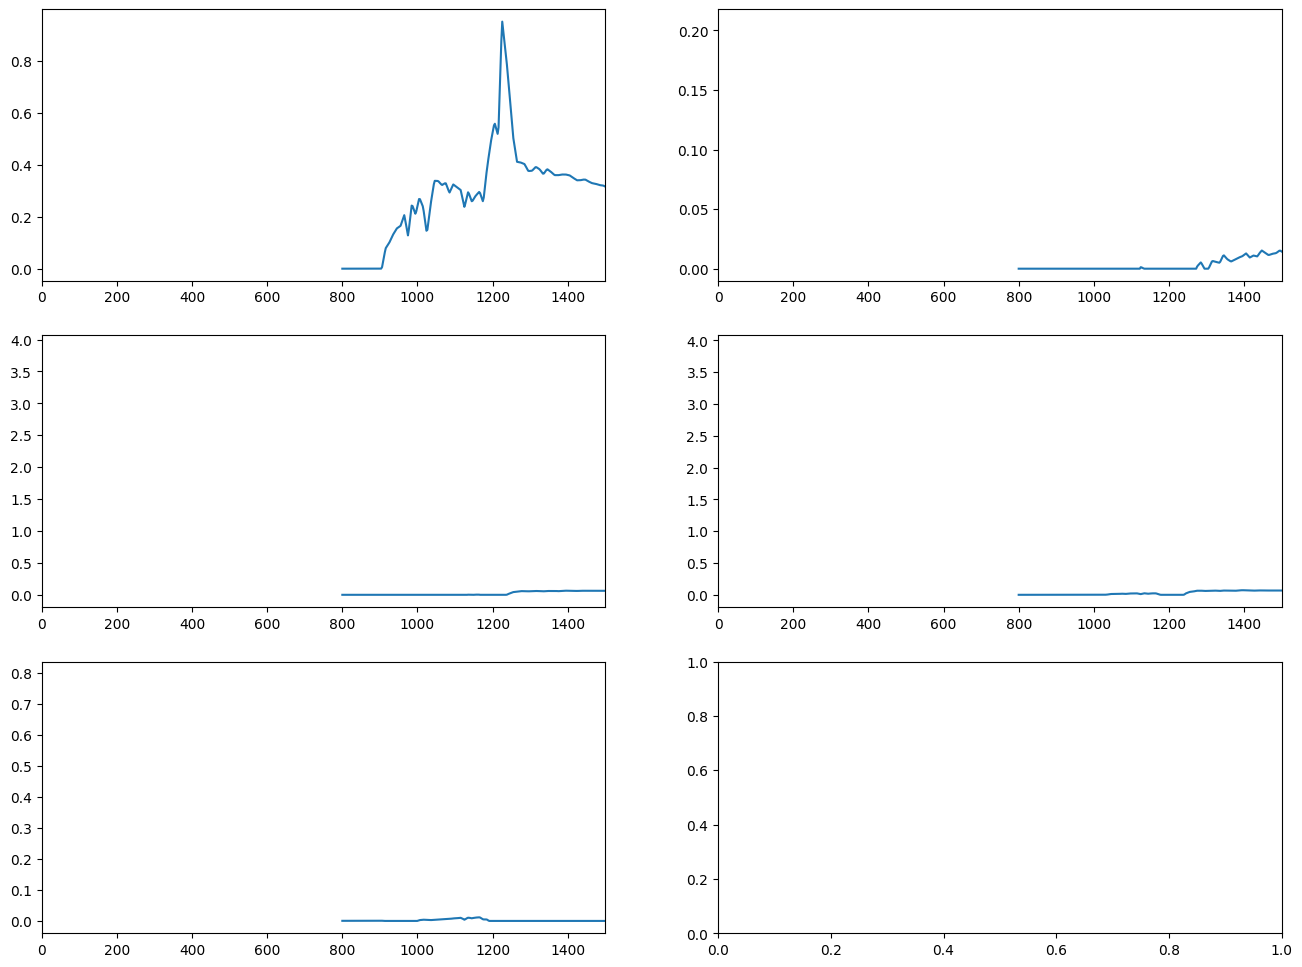

In [136]:
fig,axes=plt.subplots(3,2,figsize=(16,12))
axes=axes.flatten()
for i in range(5):
    ax=axes[i]
    ax.plot(wave_grid,H[i])
    ax.set_xlim(0,1500)
plt.show()

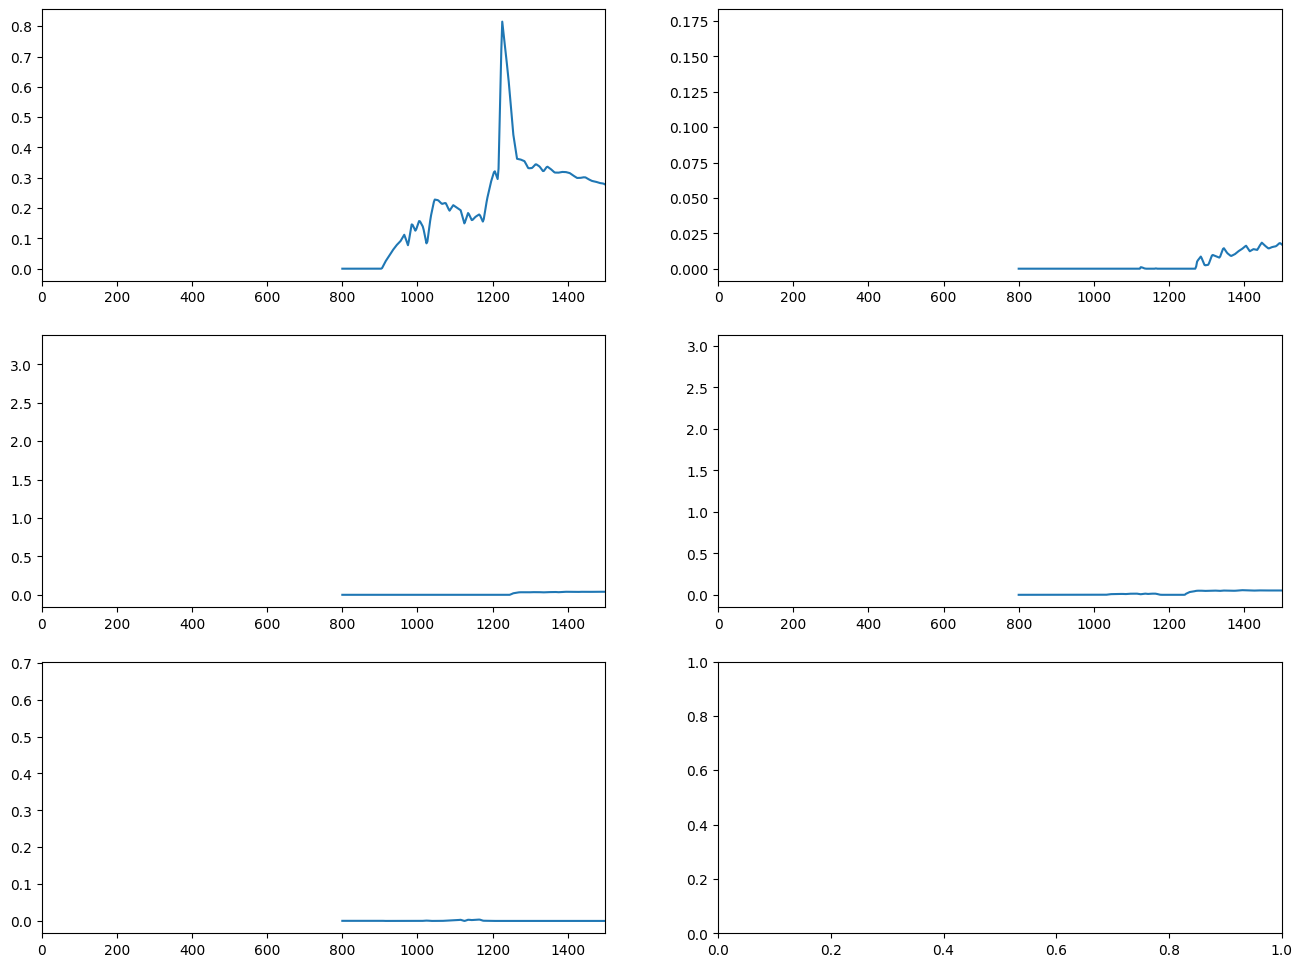

In [129]:
fig,axes=plt.subplots(3,2,figsize=(16,12))
axes=axes.flatten()
for i in range(5):
    ax=axes[i]
    ax.plot(wave_grid,H[i])
    ax.set_xlim(0,1500)
plt.show()

In [99]:
zg,fz=redshiftpca(filters,wave_grid,H)

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


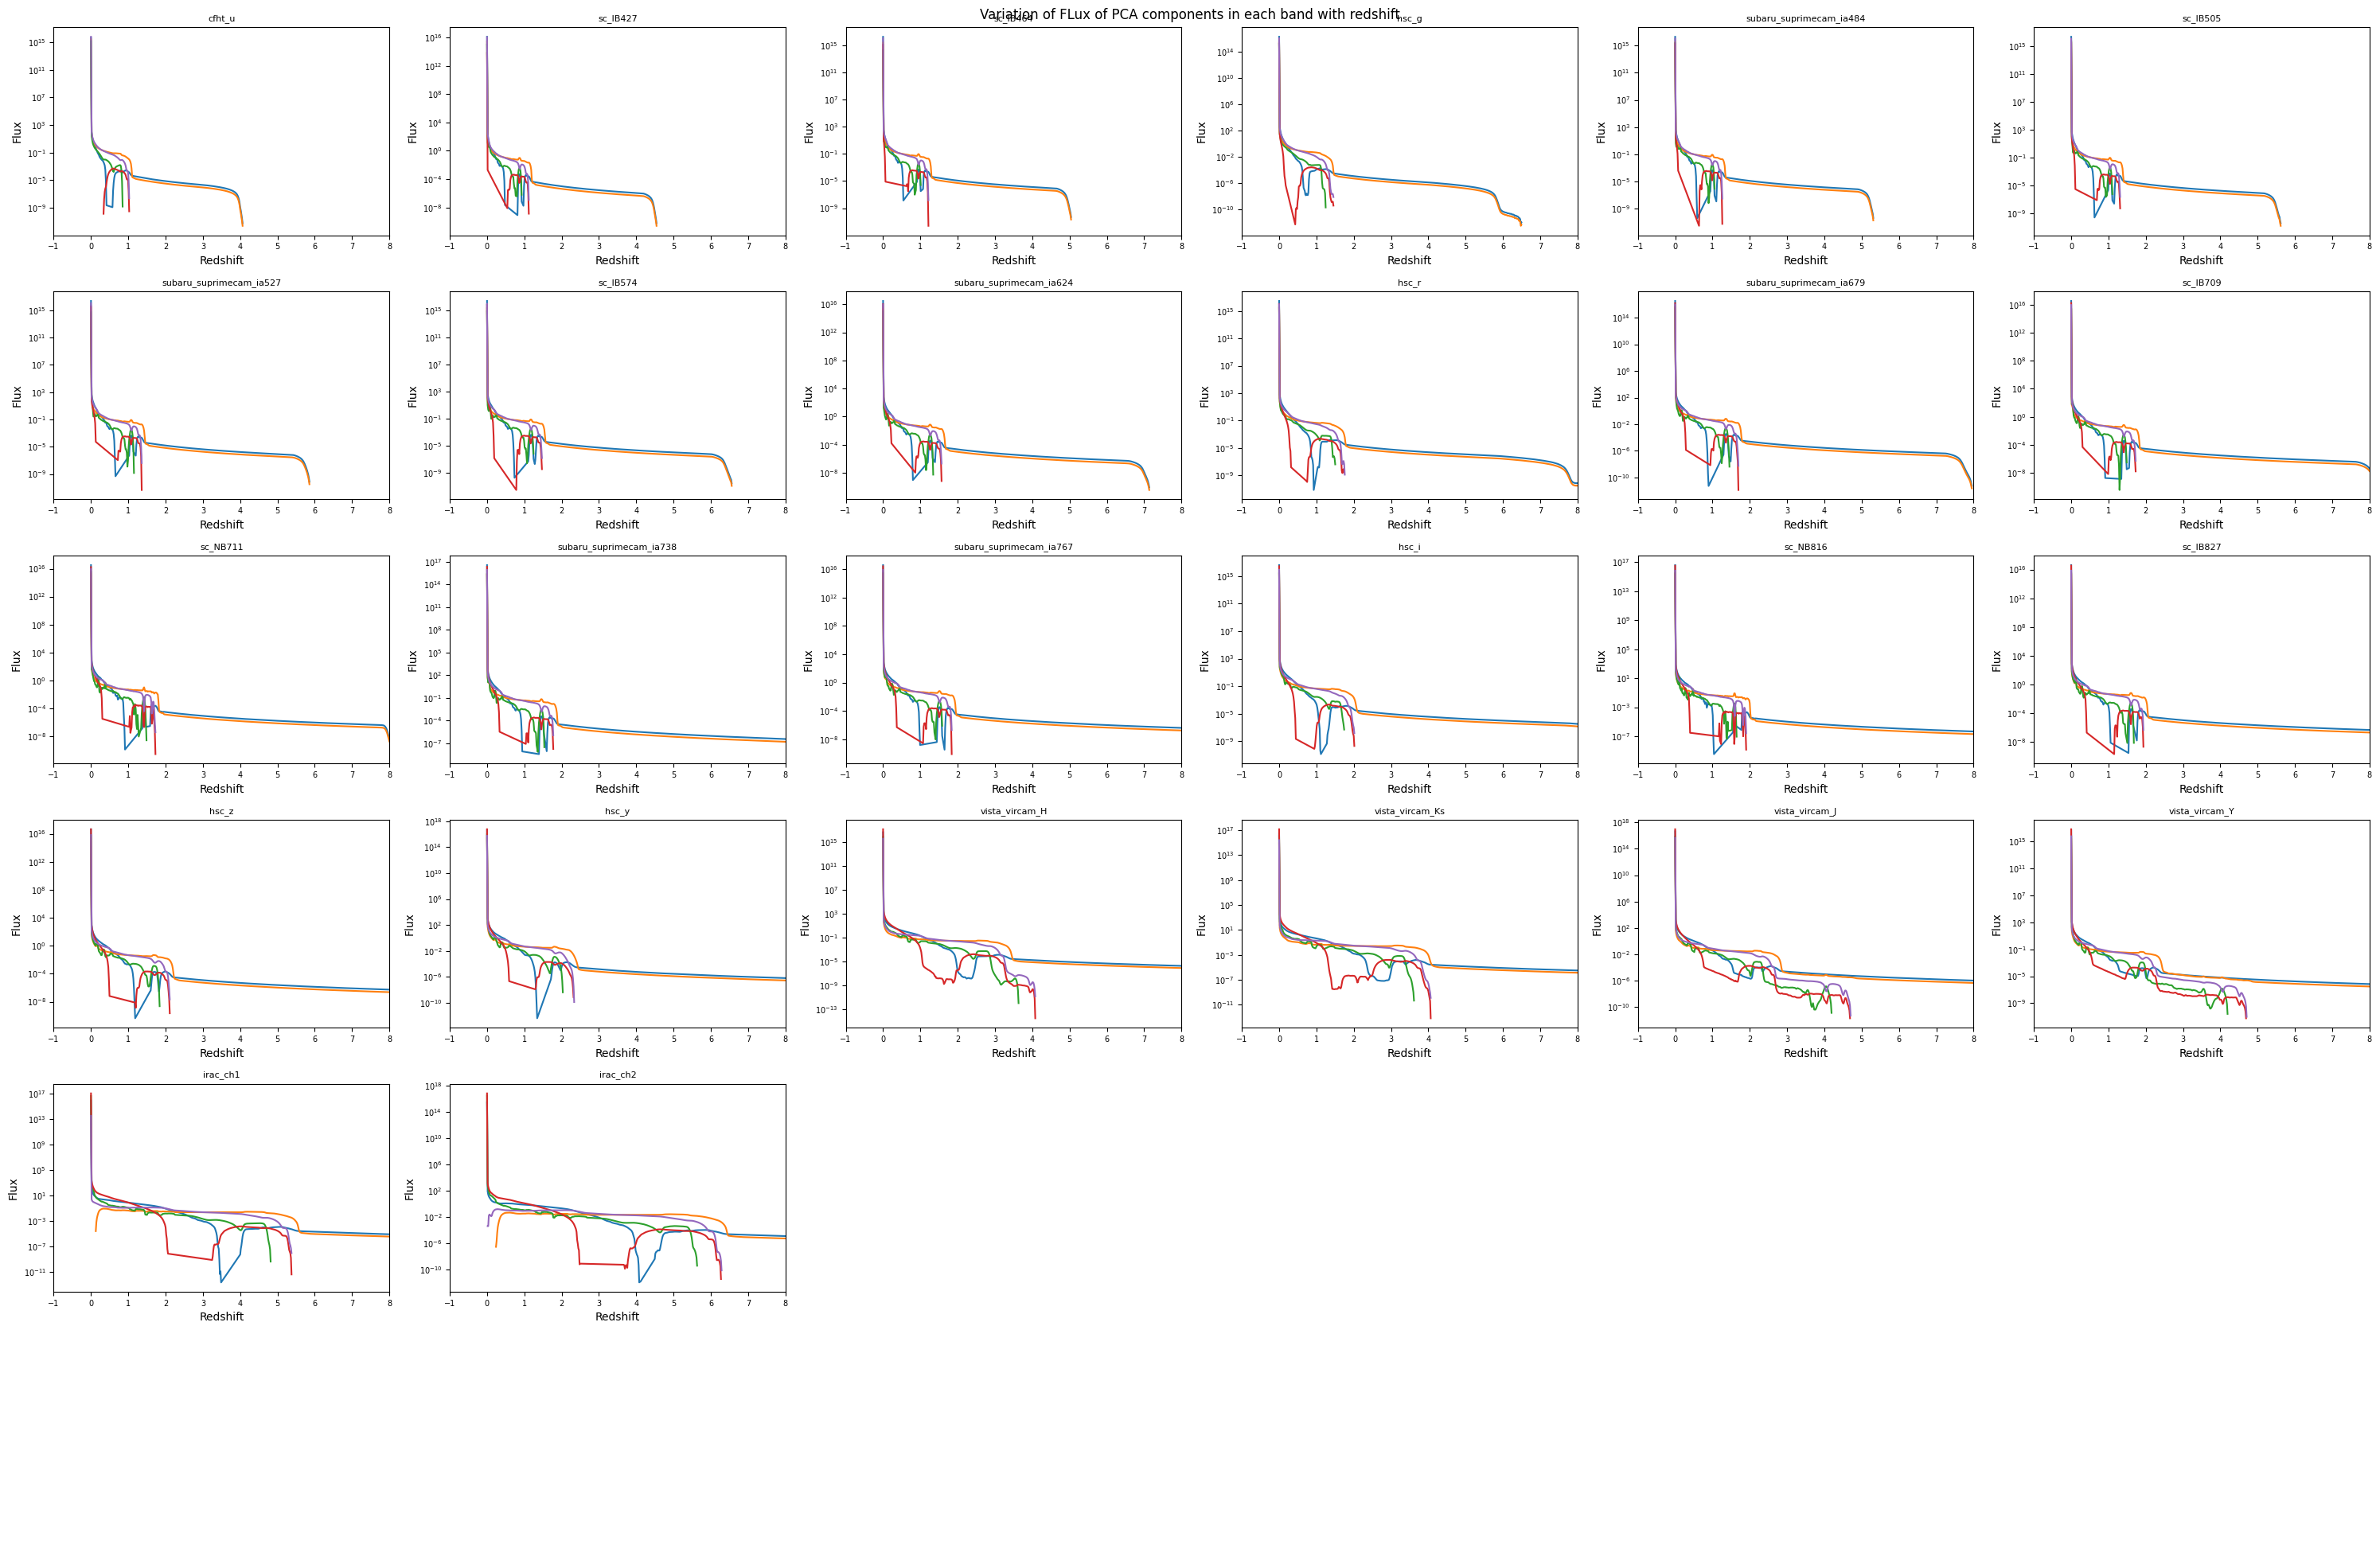

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Sort redshifts (keys)

# Convert f_z into a stacked array of shape (n_z, 4, 23)
f_all = np.array([fz[z] for z in zg])  # shape: (n_z, 4, 23)
f_all = np.nan_to_num(f_all, nan=0.0)

n_pca, n_filters = f_all.shape[1], f_all.shape[2]

fig, axes = plt.subplots(6, 6, figsize=(30, 20), sharex=False, sharey=False)
axes = axes.flatten()

for filt_idx in range(n_filters):
    ax = axes[filt_idx]
    fluxes = f_all[:, :, filt_idx]  # shape (n_z, n_pca)
    
    for comp_idx in range(n_pca):
        flux = fluxes[:, comp_idx]
        
        # mask out regions where flux is zero or negligible
        mask = flux > 0
        if np.sum(mask) == 0:
            continue  # nothing to plot for this component
        
        # only keep valid parts of the curve
        z_valid = np.array(zg)[mask]
        flux_valid = flux[mask]

        ax.plot(z_valid, flux_valid, label=f'PCA {comp_idx+1}')

    ax.set_title(f'{fil[filt_idx]}', fontsize=8)
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Flux')
    ax.set_yscale('log')
    ax.set_xlim(-1,8)
    ax.tick_params(labelsize=7)
    #ax.relim()
    #ax.autoscale(enable=True, axis='both', tight=True)
    #ax.legend(fontsize=6)

# Hide unused subplots
for ax in axes[n_filters:]:
    ax.axis('off')

# Legend only on the first plot

plt.suptitle('Variation of FLux of PCA components in each band with redshift')
plt.tight_layout()
plt.show()




In [102]:
#f_all = np.load('pcaflux_w_redshift2.npy')   
#z_grid1=np.load('zgrid1.npy')
f_interp_vec = RegularGridInterpolator((zg,), f_all, bounds_error=False, fill_value=None)

In [103]:
tran=np.load('trans_cosmos1.npy')

In [104]:
z=df['ez_z_phot'].to_numpy()
alpha=lst_sqr(f_interp_vec,z,Y,Rinv,tran,igm=True)

In [105]:
alphat=studentt_coef(f_interp_vec,z,500,alpha,Y,Rinv,tran,igm=True,nu=2)

diff [-9.51006256e+05 -8.31336015e+06  6.39506885e+08 -1.83420080e+08
  2.20726282e+07] rel diff [ 4.79827564e-04  1.25952461e-02  3.41649136e+00 -5.50620125e+00
  7.01337081e-01]
iter 30 norm 0.0006781724483088994


In [106]:
bi_all,Bi_all,M0,M1=XD(f_interp_vec,z,30,alphat,Y,Rinv,tran,igm=True,batch_size=50000,eps=1e-3)


--- EM for Redshift-Dependent Coeff Mean & Separate Redshift Mean ---
Iter 1
time = 49.1s
ΔM0 = 8969032934.224 | ΔM1 = 7779870407.704841 
relM0 = 0.9993197324800334 | relM1 = 0.9989993602642188 
Iter 2
time = 51.3s
ΔM0 = 36703621.66457405 | ΔM1 = 32501890.052524187 
relM0 = 0.34925115111841687 | relM1 = 0.28050167442931356 
Iter 3
time = 48.1s
ΔM0 = 28368038.396868903 | ΔM1 = 24757832.89465478 
relM0 = 0.394714917464549 | relM1 = 0.2869298519944205 
Iter 4
time = 49.1s
ΔM0 = 36144963.071430124 | ΔM1 = 31434967.792165667 
relM0 = 0.4853290601378291 | relM1 = 0.3657242988572664 
Iter 5
time = 50.7s
ΔM0 = 42469863.87774869 | ΔM1 = 36826350.00421313 
relM0 = 0.6361444321631888 | relM1 = 0.46009434109390007 
Iter 6
time = 50.2s
ΔM0 = 56637237.910231024 | ΔM1 = 49142812.741328254 
relM0 = 0.761791965097073 | relM1 = 0.5837759051532615 
Iter 7
time = 54.3s
ΔM0 = 78720702.06720321 | ΔM1 = 68358263.5060503 
relM0 = 1.0056097610254675 | relM1 = 0.7798992391004632 
Iter 8
time = 48.9s
ΔM0 = 8592

In [107]:
r=residuals(bi_all,f_interp_vec(z),Y,S,z,lam)

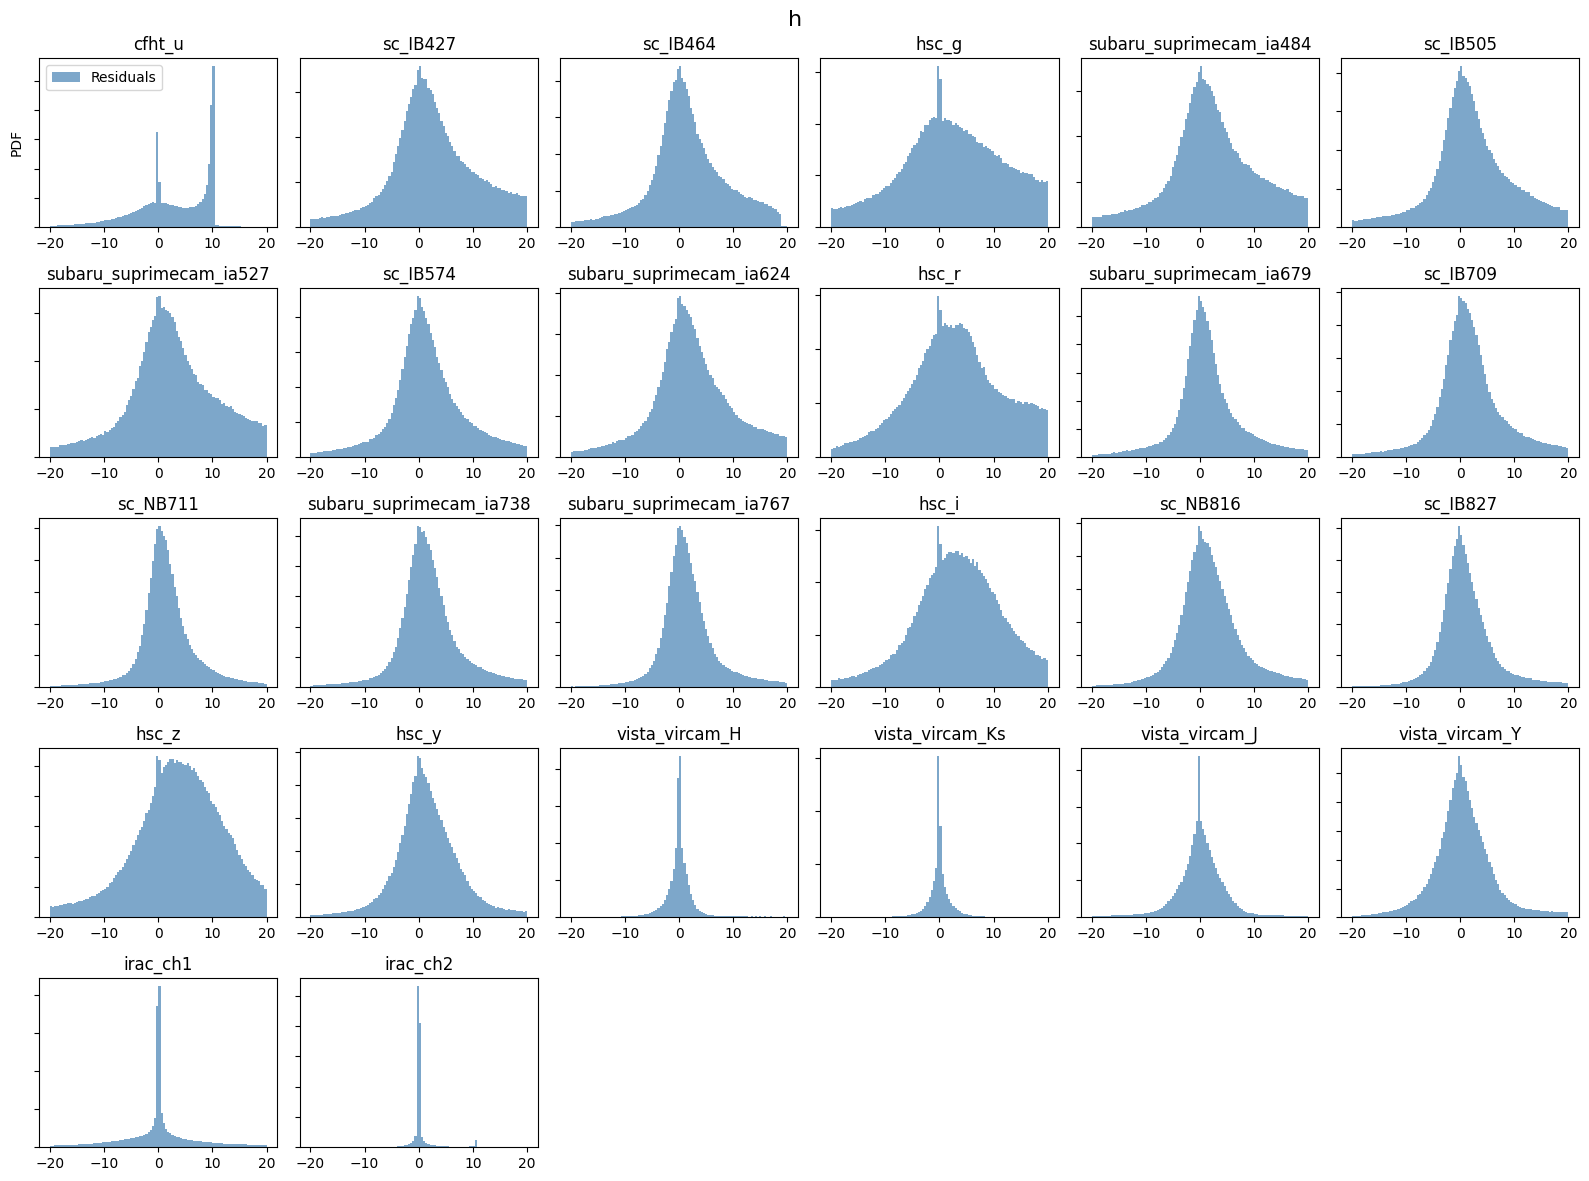

In [108]:
plot_residaul(r,'h')

In [147]:
Y_out=[]
s_out=[]
model_out=[]
z_out=[]
for idx, band_list in enumerate(r):
    res_arr = np.array(band_list, dtype=float)
    mask = (res_arr > 20) | (res_arr < -20)
    ids = np.where(mask[0])
    Y_out.append(Y.T[idx][ids])
    s_out.append(S.T[idx][ids])
    model_out.append(bi_all[ids])
    z_out.append(z[ids])
print(f"Total outliers found: {sum(len(x) for x in outlier_ids)}")

Total outliers found: 1395265
